In [1]:
import torch
from torchvision.transforms.v2 import RandomHorizontalFlip as rhflip, RandomVerticalFlip as rvflip
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm
import gc

global_path = "/home/ids/edabier/HSU"
# global_path = "/home/edabier/Documents/Thèse/benchmark"
# global_path = "/Users/edabier/Documents/Thèse/Thèse_Télécom"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
sys.path.append(f"{global_path}/SS-HSU_benchmark")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils, losses, plots, extractor
from src.models import models, upsamplers, foundation_models as rsfm, unmixers as unmx

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

/home/ids/edabier/miniconda3/envs/hsu-latest/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ids/edabier/miniconda3/envs/hsu-latest/lib/python3.14/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/ids/edabier/miniconda3/envs/hsu-latest/lib/python3.14/site-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/ids/edabier/miniconda3/envs/hsu-latest/lib/python3.14/site-packages/timm/models/registry.py:4: FutureWarn

Using device: cuda:0


In [2]:
dataset = "urban"
data = io.loadmat(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
H = Y_init.shape[-1]
A_init = utils.oneD_to_2d(A_flat)
Y_init = Y_init.unsqueeze(0)
Y_init_n = utils.standardise(Y_init)
A_init = A_init.unsqueeze(0)

if dataset == "urban4":
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt"
else:
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

In [3]:
fm_name = "DOFA"
fm, Y_init_f, new_H = rsfm.create_fm(fm_name, Y_init, size="large", version="v1", path=global_path)

_, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths)

D = int(features.shape[0])
alpha = int(features.shape[1]**0.5)

print(f"features: {features.shape}")
# plots.plot_hsi(features.reshape(D, alpha, alpha), 4)
# plt.show()
# plots.plot_pca_features(features)

# unmixer = unmx.UnmixingFromFeatures(D=D, H=new_H, alpha=alpha, B=B, c=c, upsampler="Features_fusion", n_features=1)
# sum(p.numel() for p in unmixer.upsample.parameters() if p.requires_grad)/1e6

features: torch.Size([1024, 196])


training 1/5
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.185, NMSE = 0.203
training 2/5
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.153, NMSE = 0.276
training 3/5
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.156, NMSE = 0.186
training 4/5
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.192, NMSE = 0.189
training 5/5
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.199, NMSE = 0.231
Model has 10.62652M params
Average SAD = 0.1769 ± 0.021, NMSE = 0.2169 ± 0.037


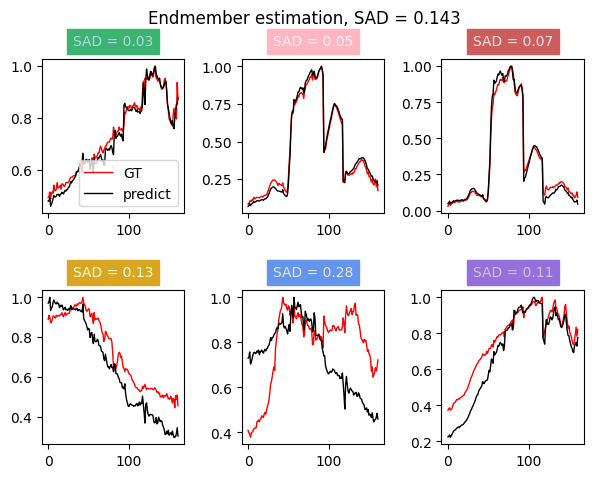

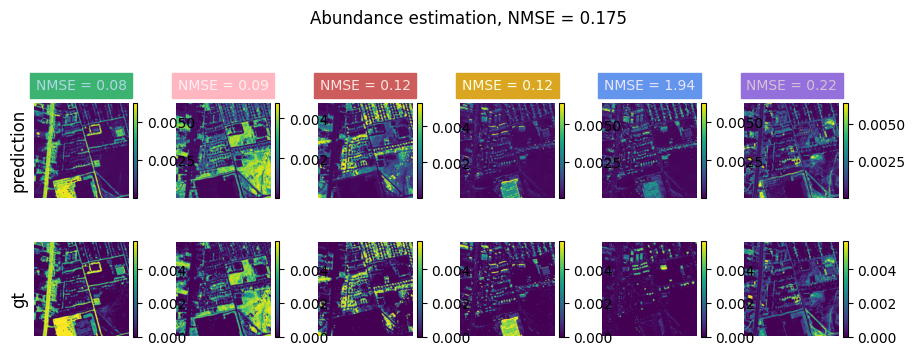

In [4]:
"""Linear upsampling of feature"""

n_xp = 5
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
upsampled_features = torch.zeros(n_xp, D, new_H, new_H)
downsample = nn.AdaptiveAvgPool2d((alpha, alpha))

for i in range(n_xp):
    print(f"training {i+1}/{n_xp}")

    model = unmx.UnmixingFromFeatures(D=D, alpha=alpha, H=new_H, B=B, c=c, upsampler="Linear", n_features=1, kernel_size=1)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)
            Y_n = utils.standardise(Y)

            _, features = rsfm.extract_f(fm, Y_n, new_H, wavelengths)
            Y_fm = rsfm.reshape_Y("DOFA", Y, new_H)

            # features = rsfm.debias_features(utils.oneD_to_2d(features), fm, B, new_H, wavelengths).flatten(1)
            E_hat, A_hat, Y_hat = model(features, Y_fm)

            # loss = model.loss(Y_fm, Y_hat, A_hat, E_hat, features_hr= model.upsample(utils.oneD_to_2d(features).unsqueeze(0), Y_fm)[0], features_lr=utils.oneD_to_2d(features))
            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():
        
        _, features = rsfm.extract_f(fm, Y_n, new_H, wavelengths)
        Y_fm, A_init_fm = rsfm.reshape_Y("DOFA", Y, new_H, A_init)
        # features = rsfm.debias_features(utils.oneD_to_2d(features), fm, B, new_H, wavelengths).flatten(1)
        E_hat, A_hat, _ = model(features, Y_fm)
        # E_hat, A_hat, A_init_fm = TTA(model, fm, Y, new_H, wavelengths, A_init)
        upsampled_features[i] = utils.oneD_to_2d(model.upsample(features))
        # upsampled_features[i] = model.upsample(utils.oneD_to_2d(features).unsqueeze(0), Y_fm)

        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True)
print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.4f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.4f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

features: torch.Size([1024, 196])


(np.float64(-0.5), np.float64(13.5), np.float64(13.5), np.float64(-0.5))

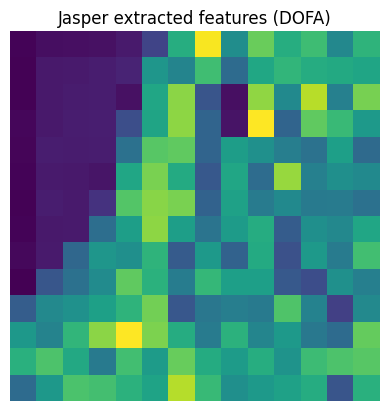

In [22]:
fm_name = "DOFA"
fm, Y_init_f, new_H = rsfm.create_fm(fm_name, Y_init, size="large", version="v1", path=global_path)

_, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths)

D = int(features.shape[0])
alpha = int(features.shape[1]**0.5)

print(f"features: {features.shape}")
plt.imshow(utils.oneD_to_2d(features)[0].detach().cpu())
plt.title("Jasper extracted features (DOFA)")
plt.axis("off")

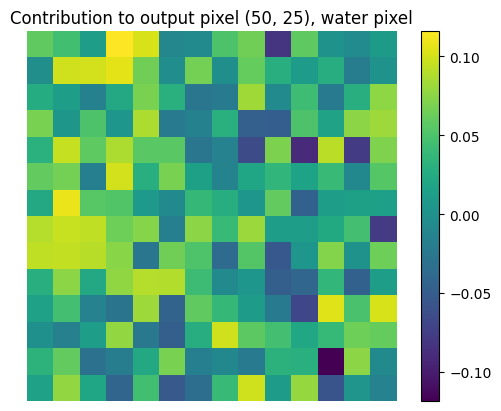

In [23]:
i, j = 50, 25
W = model.upsample.weight
W = W.reshape(int(W.shape[0]**0.5), int(W.shape[0]**0.5), int(W.shape[1]**0.5), int(W.shape[1]**0.5))
plt.imshow(W[i, j].detach().cpu(), cmap="viridis")
plt.title(f"Contribution to output pixel ({i}, {j}), water pixel")
plt.colorbar()
plt.axis("off")
plt.show()

In [ ]:
# import os
# import rasterio

# path = f"{global_path}/datasets/enmap/hsis"
# with rasterio.open(path + "/" + os.listdir(path)[0]) as img:
#     Y_init = torch.from_numpy(img.read()).to(dtype=torch.float, device=dev).unsqueeze(0)

# wavelengths_path = f"{global_path}/datasets/enmap/spectralearth_wavelength.txt"
# with open(wavelengths_path, "r") as file:
#     lines = file.readlines()
#     wavelengths = [float(line.strip()) for line in lines if line.strip()]

# fm, Y_init_f, new_H = rsfm.create_fm("SpecAware", Y_init, path=global_path)
# _, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths)
# features = utils.oneD_to_2d(features)
# D, alpha, _ = features.shape

# for p in os.listdir(path):
#     with rasterio.open(path + "/" + p) as img:

#         im_name = p[:-4]
#         Y = torch.from_numpy(img.read()).to(dtype=torch.float, device=dev)
#         _, features_hr = rsfm.extract_f(fm, utils.standardise(Y).unsqueeze(0), new_H, wavelengths)
#         features_lr = F.interpolate(utils.oneD_to_2d(features_hr).unsqueeze(0), size=(alpha//2, alpha//2))

#         torch.save(features_hr, f"{global_path}/datasets/enmap/features_hr_specaware/{im_name}.pt")
#         torch.save(features_lr, f"{global_path}/datasets/enmap/features_lr_specaware/{im_name}.pt")

In [ ]:
""" 10 times 15 trainings averaged"""

n_xp = 10
mses, sads = [], []
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

for i in range(n_xp):
    print(f"Xp {i+1}/{n_xp}")
    n_train=15
    E_hats, A_hats = torch.zeros(n_train, B, c), torch.zeros(n_train, c, new_H, new_H)
    
    for k in range(n_train):
        print(f"training {k+1}/{n_train}")

        model = unmx.UnmixingFromFeatures(D=D, alpha=alpha, H=new_H, B=B, c=c, upsampler="Features_fusion", n_features=1)
        model.apply(model.weights_init)
        model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

        epochs, lr = 200, 0.002
        optim_wrapper = dict(
            optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
            constructor='LayerDecayOptimizerConstructor_ViT',
            paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
        optimizer = build_optim_wrapper(model, optim_wrapper)

        for _ in range(epochs):

            for Y, _, _ in loader:
            
                optimizer.zero_grad()

                Y = utils.oneD_to_2d(Y).to(dev)
                Y_n = utils.standardise(Y)

                _, features = rsfm.extract_f(fm, Y_n, new_H, wavelengths)
                Y_fm = rsfm.reshape_Y("DOFA", Y, new_H)

                E_hat, A_hat, Y_hat = model(features, Y_fm)

                loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
                optimizer.step()
                
                with torch.no_grad():
                    constraints = models.weightConstraint()
                    model.decoder.apply(constraints)
                    
        model.eval()
        
        with torch.no_grad():
            
            _, features = rsfm.extract_f(fm, Y_n, new_H, wavelengths)
            Y_fm, A_init_fm = rsfm.reshape_Y("DOFA", Y, new_H, A_init)
            E_hat, A_hat, _ = model(features, Y_fm)
            E_hats[k] = E_hat
            A_hats[k] = A_hat.squeeze(0)

    E_hat_m = torch.mean(E_hats, dim=0)
    A_hat_m = torch.mean(A_hats, dim=0)
    sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_A=False, plot_E=False)
    sads.append(sad)
    mses.append(mse)        
    print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalize_E=True, normalize_A=True)
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.4f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.4f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

Xp 1/10
training 1/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 2/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 3/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 4/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 5/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 6/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 7/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 8/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 9/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 10

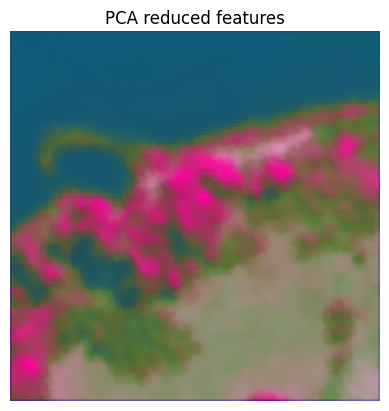

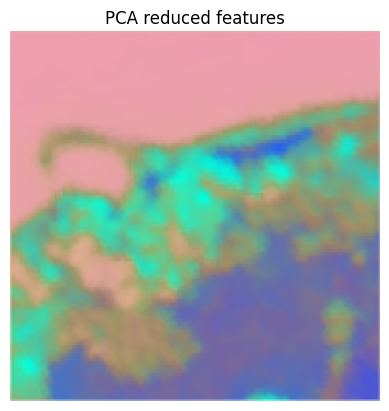

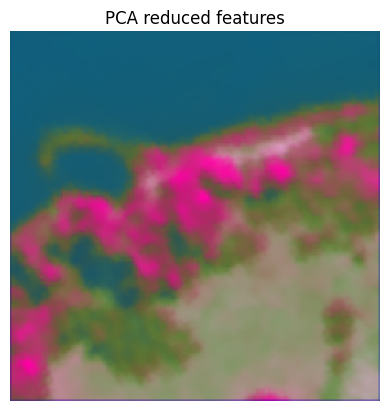

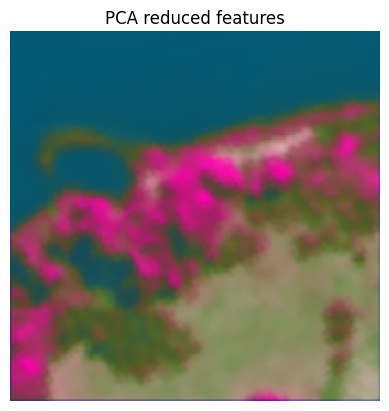

In [19]:
i=0
plots.plot_pca_features(upsampled_features[i].flatten(1))
plots.plot_pca_features(upsampled_features[i+1].flatten(1))
plots.plot_pca_features(upsampled_features[i+2].flatten(1))
plots.plot_pca_features(upsampled_features[i+3].flatten(1))

In [17]:
# """Linear upsampling of abundances"""

# n_xp = 10
# mses, sads = [], []
# E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
# loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

# for i in range(n_xp): 
#     print(f"training {i}/{n_xp}")

#     model = unmx.UnmixingFromFeatures2(D=D, alpha=alpha, H=new_H, B=B, c=c)
#     model.apply(model.weights_init)
#     model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

#     epochs, lr = 200, 0.002
#     optim_wrapper = dict(
#         optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
#         constructor='LayerDecayOptimizerConstructor_ViT',
#         paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
#     optimizer = build_optim_wrapper(model, optim_wrapper)

#     flag = False
    
#     for _ in range(epochs):

#         for Y, _, _ in loader:
        
#             optimizer.zero_grad()

#             Y = utils.oneD_to_2d(Y).to(dev)

#             Y_fm, features = rsfm.extract_f(fm, Y, new_H, wavelengths)

#             E_hat, A_hat, Y_hat, A_hat_lr = model(features, Y_fm)
#             Y_hat_lr = model.decoder(A_hat_lr)
#             if E_hat.isnan().any():
#                 flag=True
#                 print("nan")
#                 break

#             loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)#, alpha, Y_hat_lr)

#             loss.backward()
#             nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
#             optimizer.step()
            
#             with torch.no_grad():
#                 constraints = models.weightConstraint()
#                 model.decoder.apply(constraints)
    
#     if not flag:
#         model.eval()
        
#         with torch.no_grad():
#             _, A_init_fm, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths, A_init)
            
#             E_hat, A_hat, _, A_hat_lr = model(features, Y_fm)
#             if E_hat.isnan().any():
#                 print("Nans during test")
#             sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_E=False, plot_A=False)
#             print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
#             mses.append(mse)
#             sads.append(sad)

#         E_hats[i] = E_hat
#         A_hats[i] = A_hat.squeeze(0)

# E_hat_m = torch.mean(E_hats, dim=0)
# A_hat_m = torch.mean(A_hats, dim=0)
# sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True)
# print(f"Upsampler has {sum(p.numel() for p in model.upsample.parameters() if p.requires_grad)/1e6}M params")
# print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, MSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

In [ ]:
# """Linear upsampling of abundances from learned E_hat"""

# loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

# model = unmx.UnmixingFromFeatures2(D=D, alpha=alpha, H=new_H, B=B, c=c)
# model.apply(model.weights_init)
# state_dict = model.decoder.state_dict()
# state_dict["decoder.weight"][:,:,0,0] = E_hat_m
# model.decoder.load_state_dict(state_dict)
# for param in model.decoder.parameters():
#     param.requires_grad = False

# epochs, lr = 200, 0.002
# optim_wrapper = dict(
#     optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
#     constructor='LayerDecayOptimizerConstructor_ViT',
#     paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
# optimizer = build_optim_wrapper(model, optim_wrapper)

# for _ in range(epochs):

#     for Y, _, _ in loader:
    
#         optimizer.zero_grad()

#         Y = utils.oneD_to_2d(Y).to(dev)

#         Y_fm, features = rsfm.extract_f(fm, Y, new_H, wavelengths)

#         E_hat, A_hat, Y_hat, A_hat_lr = model(features)
#         Y_hat_lr = model.decoder(A_hat_lr)

#         loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)#, alpha, Y_hat_lr)

#         loss.backward()
#         nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
#         optimizer.step()
        
#         with torch.no_grad():
#             constraints = models.weightConstraint()
#             model.decoder.apply(constraints)
            
# model.eval()

# with torch.no_grad():
#     _, A_init_fm, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths, A_init)
#     E_hat, A_hat, _, A_hat_lr = model(features)
#     sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True)
#     # print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")

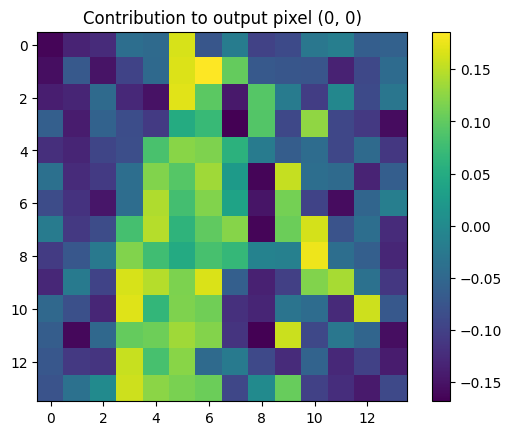

In [ ]:
# W = model.upsample.weight
# W = W.reshape(int(W.shape[0]**0.5), int(W.shape[0]**0.5), int(W.shape[1]**0.5), int(W.shape[1]**0.5))
# i, j = 0, 0  # Example: top-left output pixel
# plt.imshow(W[i, j].detach().cpu(), cmap="viridis")
# plt.title(f"Contribution to output pixel ({i}, {j})")
# plt.colorbar()
# plt.show()

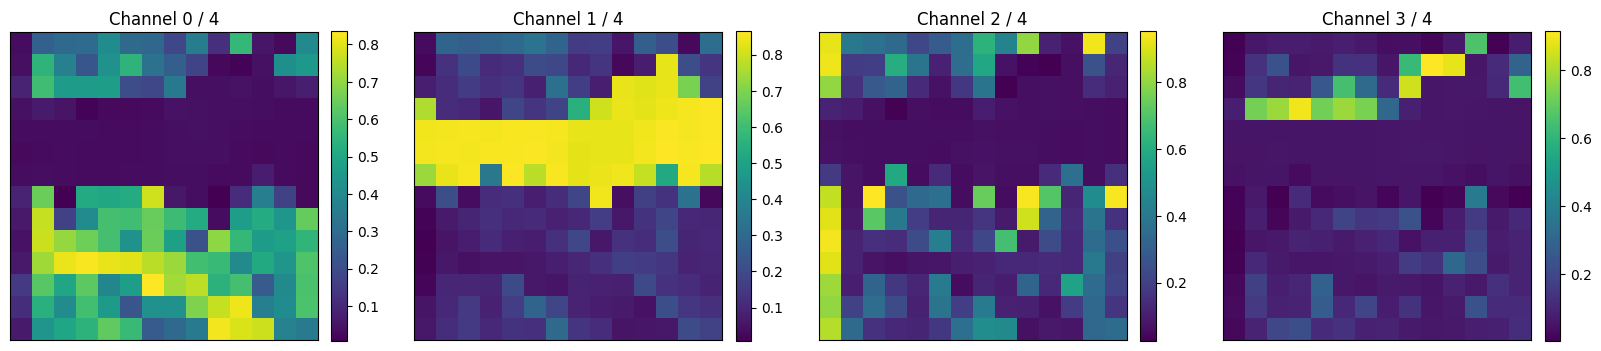

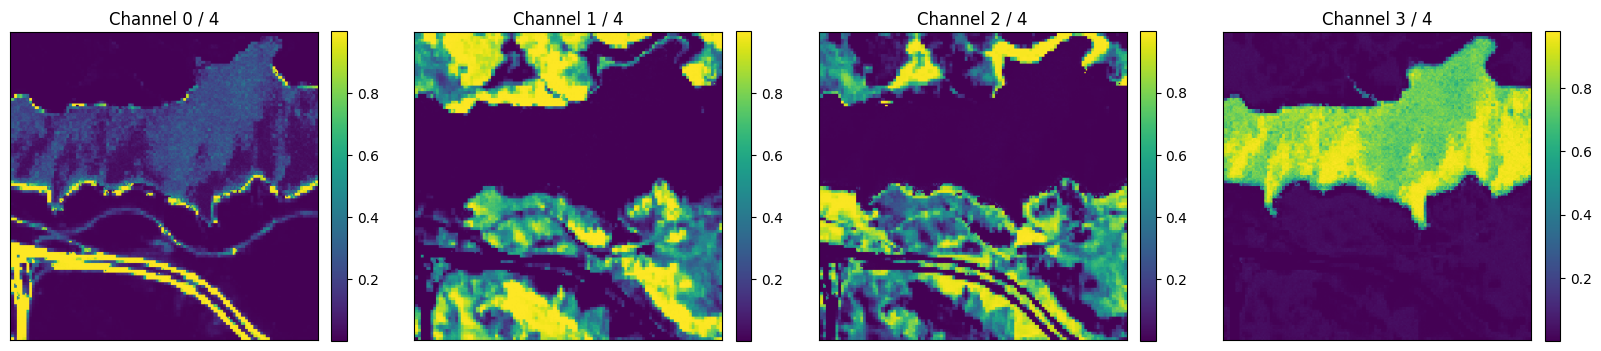

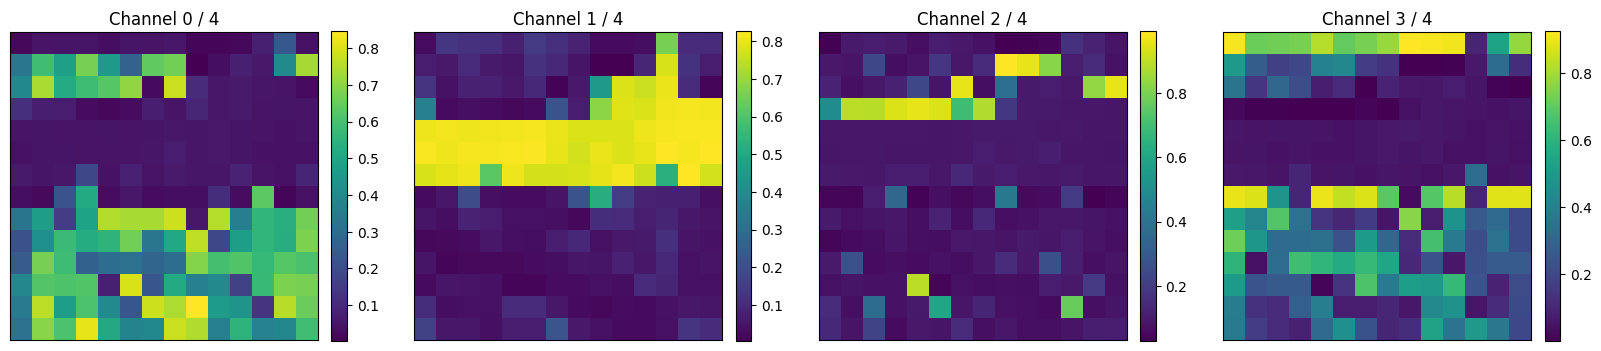

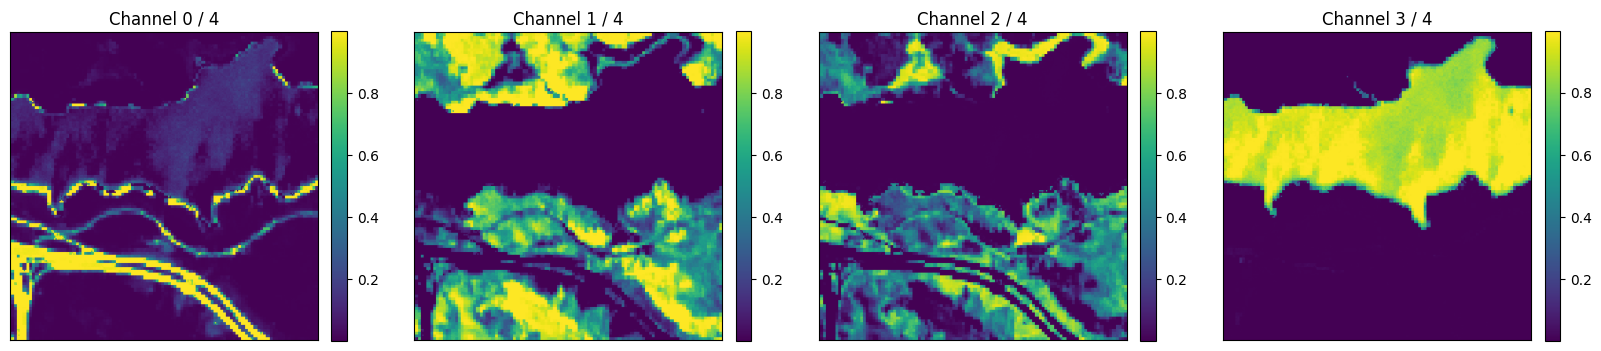

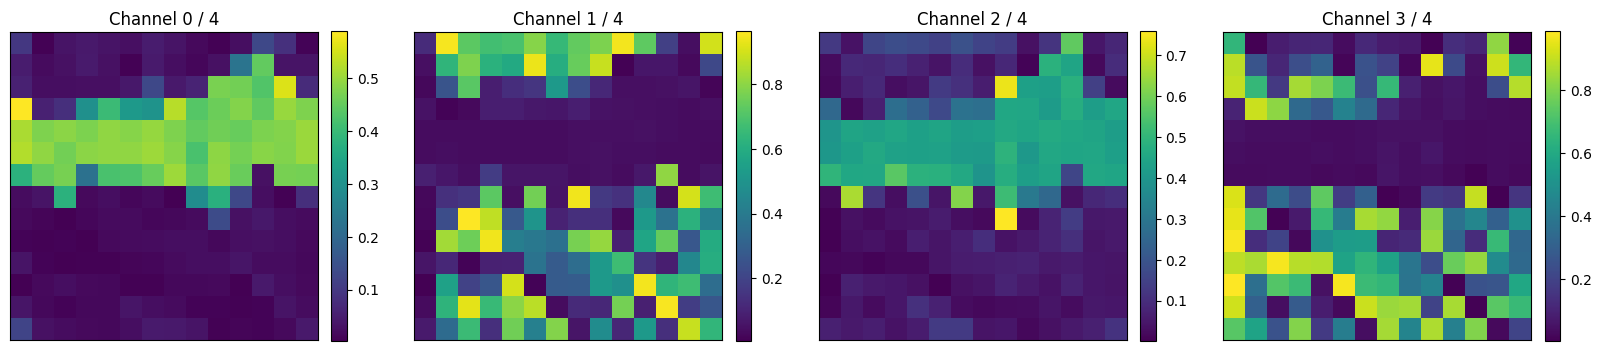

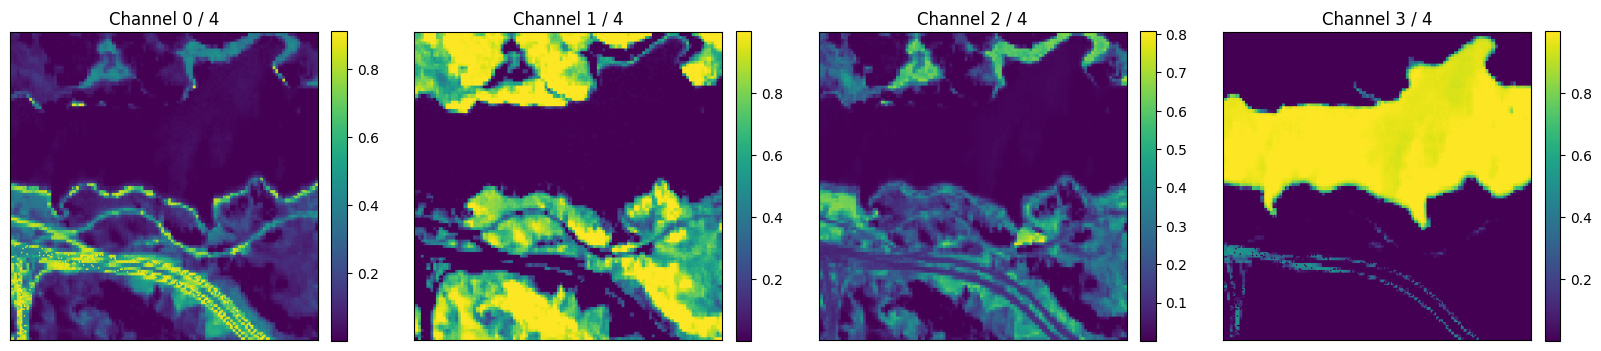

In [ ]:
for i in range(n_xp):
    plots.plot_hsi(lr_abundances[i])
    plots.plot_hsi(upsampled_abundances[i])

In [ ]:
mse_loss = nn.MSELoss()

E_hat_2, A_hat_m_2, _ = utils.order_endmembers(E_init, E_hat_m, A_hat_m)
rmse = torch.sqrt(mse_loss(A_init, A_hat_m_2))
rmse

/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/torch/utils/_device.py:103: UserWarning: Using a target size (torch.Size([3, 95, 95])) that is different to the input size (torch.Size([1, 3, 95, 95])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return func(*args, **kwargs)


tensor(0.1635, device='cuda:0')